PROGRESSIVE AUGMENTATION

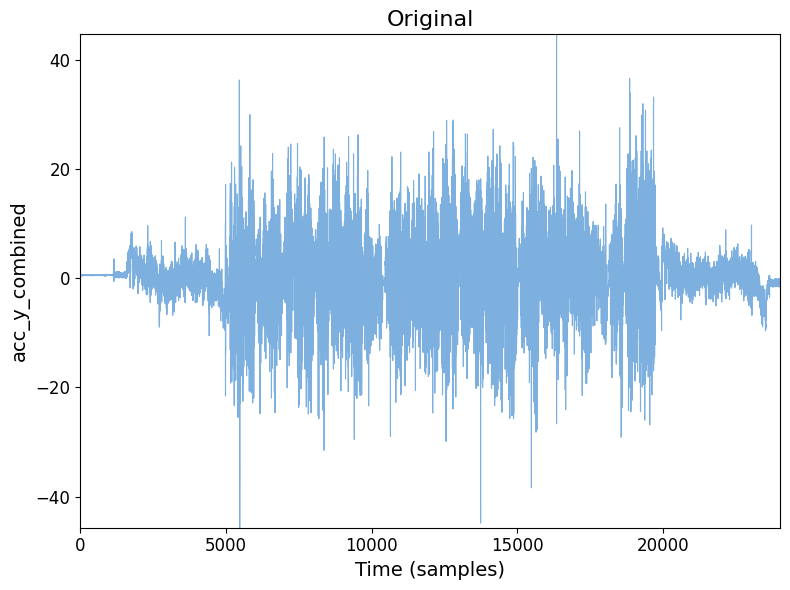

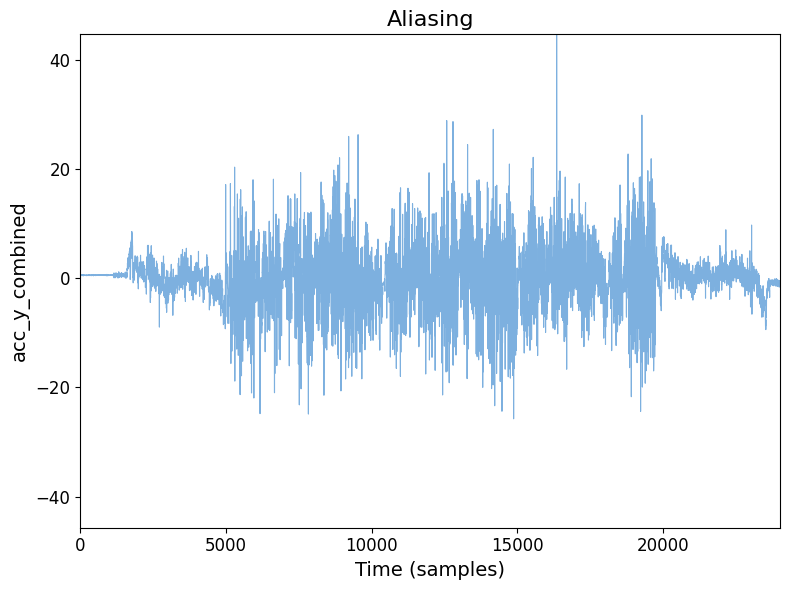

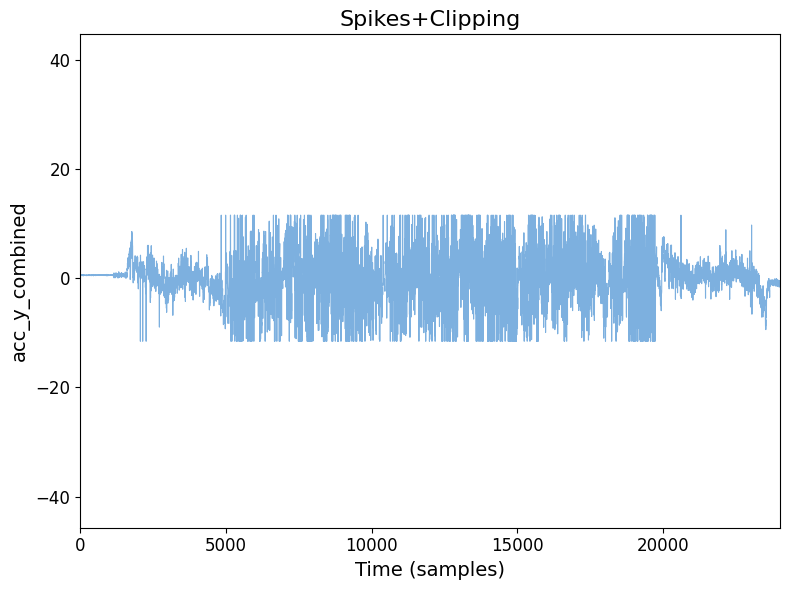

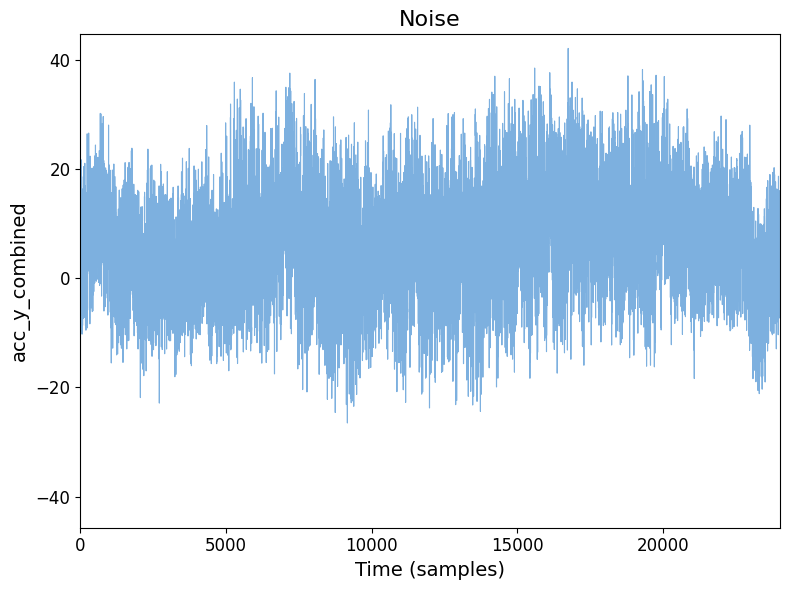

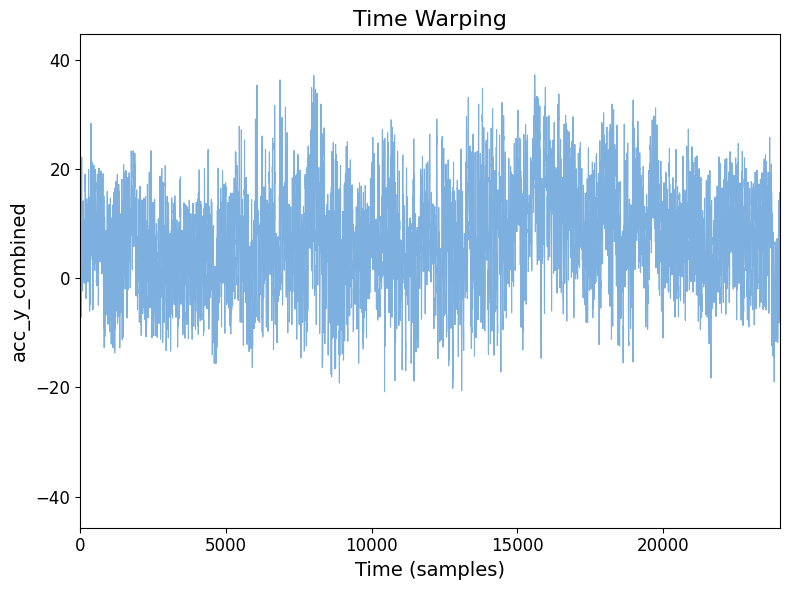

In [ ]:
# Sensor data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional
import timeseries_tools


def visualize_signal_progression(
    csv_path: str,
    col: str = "acc_y_combined",
    sample_rate_hz: float = 100.0,
    downsample_ratio: float = 1.0,
    reduced: bool = True,
):
    """
    Show signal progression through degradation steps (each 800x600 px).

    Args:
        csv_path: Path to input CSV file.
        col: Column name of signal.
        sample_rate_hz: Sample rate for noise component.
        downsample_ratio: Ratio (0 < r <= 1) of how much to downsample before processing.
        reduced: If True -> realistic-light degradation (for visualization).
                 If False -> full heavy degradation chain.
    """
    df = pd.read_csv(csv_path)
    y_full = df[col].to_numpy(np.float32)

    # --- Downsample BEFORE processing ---
    if 0 < downsample_ratio < 1:
        step = int(1 / downsample_ratio)
        y = y_full[::step]
    else:
        y = y_full.copy()

    # Ensure correct shape
    y2d, _ = timeseries_tools._ensure_2d(y)
    rng = np.random.default_rng(42)

    # --- Step 1: Original ---
    signals = [("Original", y2d.squeeze())]

    # --- Step 2: Aliasing ---
    y_alias = timeseries_tools._alias_then_restore(y2d, factor=4, method="zoh")
    signals.append(("Aliasing", y_alias.squeeze()))

    # --- Step 3: Spikes + Clipping ---
    y_spike = y_alias.copy()
    T, C = y_spike.shape
    n_spikes = 10
    spike_scale_sigma = 12.0
    clip_sigma = 2.0
    spike_idx = rng.choice(T, size=min(n_spikes, T), replace=False)
    for c in range(C):
        sd = float(y_spike[:, c].std() or 1.0)
        amp = spike_scale_sigma * sd
        signs = rng.choice(np.array([-1.0, 1.0], dtype=np.float32), size=len(spike_idx))
        y_spike[spike_idx, c] += signs * amp
        limit = clip_sigma * sd
        y_spike[:, c] = np.clip(y_spike[:, c], -limit, limit)
    signals.append(("Spikes+Clipping", y_spike.squeeze()))

    # --- Step 4: Noise ---
    if reduced:
        noise_kwargs = dict(
            noise_color="mixture",
            mixture_weights=(0.3, 0.4, 0.3),
            target_snr_db=-1.0,  # less noise than before
            periodic_amp=1.0,
            periodic_freq_hz=6.0,
            sample_rate_hz=sample_rate_hz,
        )
        y_noise = timeseries_tools.noisy_augment_signal(y_spike, **noise_kwargs)
    else:
        noise_kwargs = dict(
            noise_color="mixture",
            mixture_weights=(0.3, 0.4, 0.3),
            target_snr_db=-8.0,
            periodic_amp=1.0,
            periodic_freq_hz=6.0,
            sample_rate_hz=sample_rate_hz,
        )
        y_noise = timeseries_tools.noisy_augment_signal(y_spike, **noise_kwargs)
    signals.append(("Noise", y_noise.squeeze()))

    # --- Step 5: Time Warping ---
    if reduced:
        time_warp_strength = 0.75   # slightly stronger than before
        time_warp_knots = 100
    else:
        time_warp_strength = 10.0
        time_warp_knots = 200


    time_warp_strength = 10.0
    time_warp_knots = 200
    y_warp = _safe_time_warp_um(
        y_noise, strength=time_warp_strength, knots=time_warp_knots, rng=rng
    )
    signals.append(("Time Warping", y_warp.squeeze()))

    # ---------------------------------------------------------
    # Display each step as its own 800x600 px figure
    # ---------------------------------------------------------
    ymin = min(s.min() for _, s in signals)
    ymax = max(s.max() for _, s in signals)
    xlim = (0, len(signals[0][1]))

    for label, sig in signals:
        plt.figure(figsize=(8, 6), dpi=100)
        plt.plot(sig, color="#6fa8dc", linewidth=0.8, alpha=0.9)  # light blue line
        plt.title(label, fontsize=16)
        plt.xlim(xlim)
        plt.ylim(ymin, ymax)
        plt.xlabel("Time (samples)", fontsize=14)
        plt.ylabel(col, fontsize=14)
        plt.tick_params(labelsize=12)
        plt.tight_layout()
        plt.show()



# ---------------------------------------------------------
# Safe time-warping wrapper (prevents disappearing sections)
# ---------------------------------------------------------
def _safe_time_warp_um(
    y: np.ndarray, strength: float = 0.10, knots: int = 4, rng: Optional[np.random.Generator] = None
) -> np.ndarray:
    """Stable version of time-warping — ensures monotonic tau and same output length."""
    if rng is None:
        rng = np.random.default_rng()
    y2d, squeezed = timeseries_tools._ensure_2d(y)
    T, C = y2d.shape

    # Random offsets at control points
    xk = np.linspace(0, T - 1, knots, dtype=np.float32)
    yk = rng.normal(0.0, strength, size=knots).astype(np.float32)
    curve = np.interp(np.arange(T, dtype=np.float32), xk, yk).astype(np.float32)

    # Convert to positive speeds (avoid overflow for large strength)
    curve = np.clip(curve, -5, 5)
    speed = np.exp(curve).astype(np.float32)

    # Create monotonically increasing tau
    tau = np.cumsum(speed)
    tau = (tau - tau[0]) / (tau[-1] - tau[0] + 1e-8) * (T - 1)
    tau = np.clip(tau, 0, T - 1)
    t_full = np.arange(T, dtype=np.float32)

    # Resample with interpolation
    y_warp = np.empty_like(y2d)
    for c in range(C):
        y_warp[:, c] = np.interp(t_full, tau, y2d[:, c], left=y2d[0, c], right=y2d[-1, c])
    return y_warp.squeeze(-1) if squeezed else y_warp


# ---------------------------------------------------------
# Example usage
# ---------------------------------------------------------
# visualize_signal_progression("/path/to/your.csv", col="acc_y_combined", downsample_ratio=0.2, reduced=True)
# visualize_signal_progression("/path/to/your.csv", col="acc_y_combined", downsample_ratio=0.2, reduced=False)
visualize_signal_progression("/home/ws/ugoby/master_thesis/data_conference/labels/synchronized_labels_mpu_left_PVS1.csv", col="acc_y_combined", downsample_ratio=0.15, reduced=True)

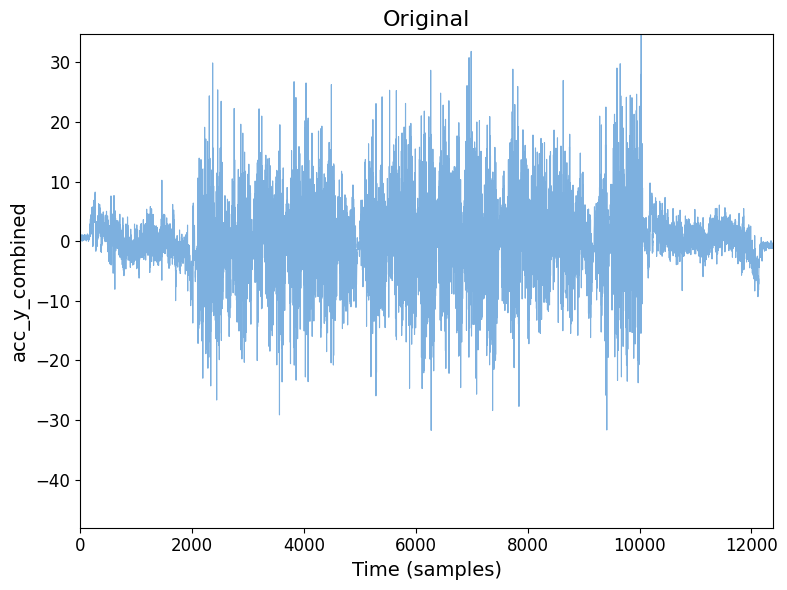

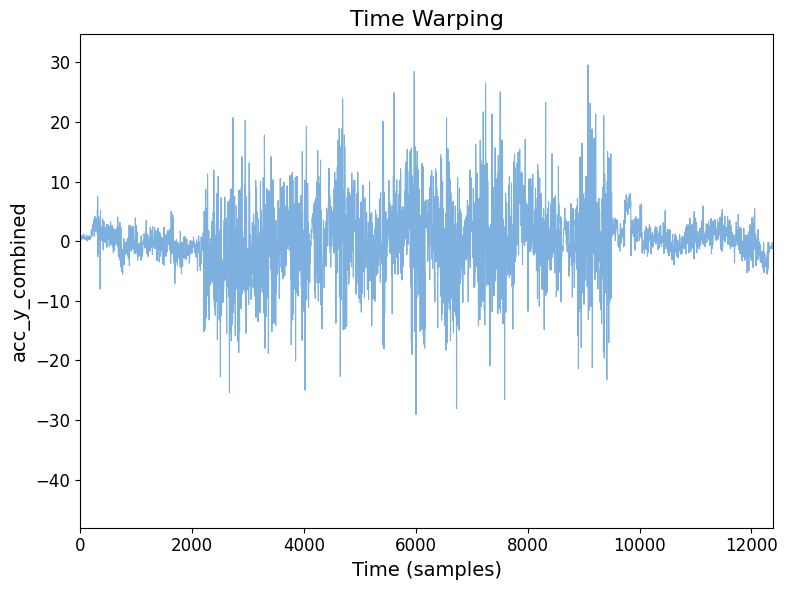

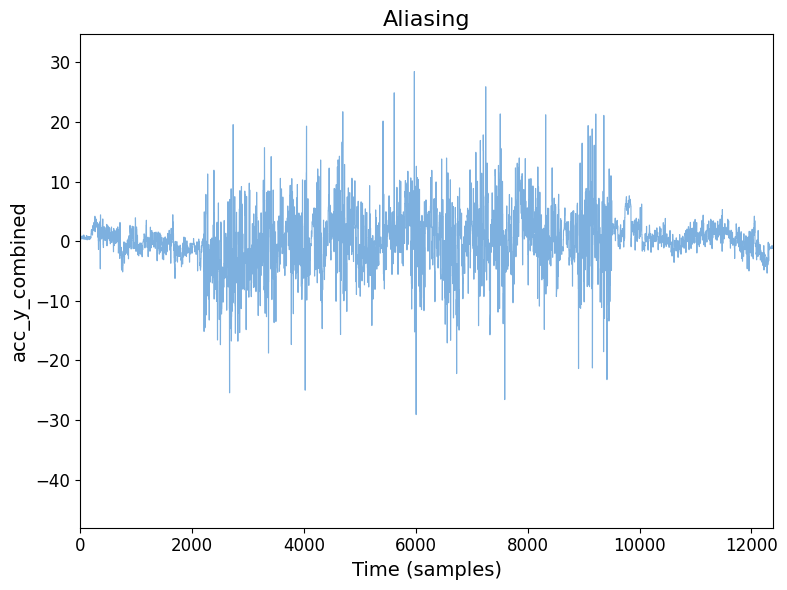

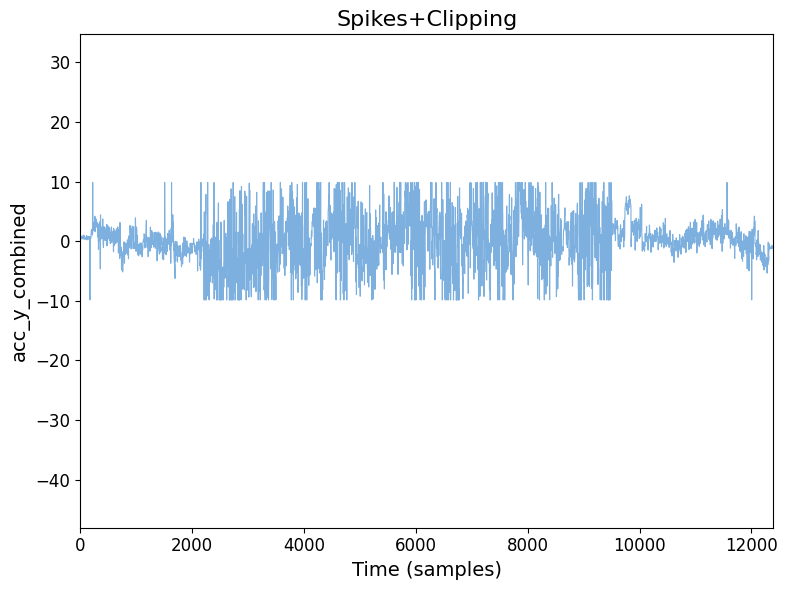

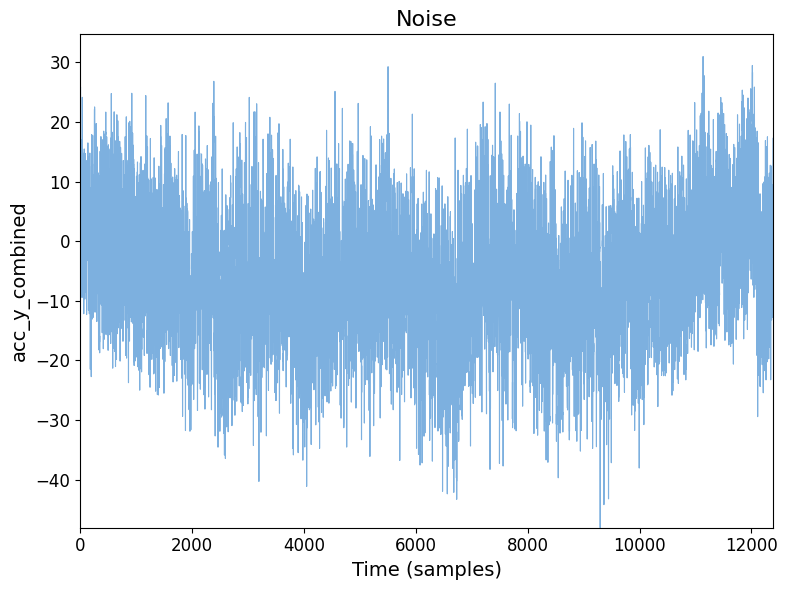

In [5]:
def visualize_signal_progression(
    csv_path: str,
    col: str = "acc_y_combined",
    sample_rate_hz: float = 100.0,
    downsample_ratio: float = 1.0,
):
    """
    Show signal progression through degradation steps using the exact parameters
    from LEVEL "1_pvs1_mfcc++" in timeseries_tools, preserving correct order:
    Time Warp → Aliasing → Spikes+Clipping → Noise
    """
    df = pd.read_csv(csv_path)
    y_full = df[col].to_numpy(np.float32)

    # --- Downsample BEFORE processing ---
    if 0 < downsample_ratio < 1:
        step = int(1 / downsample_ratio)
        y = y_full[::step]
    else:
        y = y_full.copy()

    # Ensure correct shape
    y2d, _ = timeseries_tools._ensure_2d(y)
    rng = np.random.default_rng(42)

    # --- Step 1: Original ---
    signals = [("Original", y2d.squeeze())]

    # --- Step 2: Time Warping (enabled=True, strength=10, knots=200) ---
    time_warp_strength = 10.0
    time_warp_knots = 200
    y_warp = _safe_time_warp_um(
        y2d, strength=time_warp_strength, knots=time_warp_knots, rng=rng
    )
    signals.append(("Time Warping", y_warp.squeeze()))

    # --- Step 3: Aliasing (factor=4, zoh) ---
    y_alias = timeseries_tools._alias_then_restore(y_warp, factor=4, method="zoh")
    signals.append(("Aliasing", y_alias.squeeze()))

    # --- Step 4: Spikes + Clipping ---
    y_spike = y_alias.copy()
    T, C = y_spike.shape
    n_spikes = 10
    spike_scale_sigma = 12.0
    clip_sigma = 2.0
    spike_idx = rng.choice(T, size=min(n_spikes, T), replace=False)
    for c in range(C):
        sd = float(y_spike[:, c].std() or 1.0)
        amp = spike_scale_sigma * sd
        signs = rng.choice(np.array([-1.0, 1.0], dtype=np.float32), size=len(spike_idx))
        y_spike[spike_idx, c] += signs * amp
        limit = clip_sigma * sd
        y_spike[:, c] = np.clip(y_spike[:, c], -limit, limit)
    signals.append(("Spikes+Clipping", y_spike.squeeze()))

    # --- Step 5: Noise (exact noise_kwargs from LEVEL 1_pvs1_mfcc++) ---
    noise_kwargs = dict(
        noise_color="mixture",
        mixture_weights=(0.3, 0.4, 0.3),
        target_snr_db=-5.0,
        periodic_amp=1.0,
        periodic_freq_hz=6.0,
        sample_rate_hz=sample_rate_hz,
    )
    y_noise = timeseries_tools.noisy_augment_signal(y_spike, **noise_kwargs)
    signals.append(("Noise", y_noise.squeeze()))

    # ---------------------------------------------------------
    # Display each step as its own 800x600 px figure
    # ---------------------------------------------------------
    ymin = min(s.min() for _, s in signals)
    ymax = max(s.max() for _, s in signals)
    xlim = (0, len(signals[0][1]))

    for label, sig in signals:
        plt.figure(figsize=(8, 6), dpi=100)
        plt.plot(sig, color="#6fa8dc", linewidth=0.8, alpha=0.9)
        plt.title(label, fontsize=16)
        plt.xlim(xlim)
        plt.ylim(ymin, ymax)
        plt.xlabel("Time (samples)", fontsize=14)
        plt.ylabel(col, fontsize=14)
        plt.tick_params(labelsize=12)
        plt.tight_layout()
        plt.show()

# visualize_signal_progression("/path/to/your.csv", col="acc_y_combined", downsample_ratio=0.2, reduced=False)
visualize_signal_progression("/home/ws/ugoby/master_thesis/data/pvs1_X01_label.csv", col="acc_y_combined", downsample_ratio=0.09)

In [ ]:
# Video data – light (≈80% toned down, brightness/contrast +10%, stable noise +5%)

import albumentations as A
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# Helper: show image inline
# ----------------------------------------------------------
def show_step(image: np.ndarray, title: str):
    if image is None:
        raise ValueError("Image is empty – check your file path.")
    plt.figure(figsize=(8, 6), dpi=100)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.show()


# ----------------------------------------------------------
# Step functions (light pipeline with slightly stronger stable noise)
# ----------------------------------------------------------
def step1_gamma(image: np.ndarray) -> np.ndarray:
    aug = A.RandomGamma(gamma_limit=(110, 150), p=1.0)
    return aug(image=image)["image"]

def step2_brightness_contrast(image: np.ndarray) -> np.ndarray:
    aug = A.RandomBrightnessContrast(
        brightness_limit=(-0.12, 0.12),
        contrast_limit=(-0.12, 0.18),
        p=1.0
    )
    return aug(image=image)["image"]

def step3_hue_saturation(image: np.ndarray) -> np.ndarray:
    aug = A.HueSaturationValue(
        hue_shift_limit=3,
        sat_shift_limit=(-10, 10),
        val_shift_limit=(-10, 8),
        p=1.0
    )
    return aug(image=image)["image"]

def step4_tonecurve(image: np.ndarray) -> np.ndarray:
    aug = A.RandomToneCurve(scale=0.05, p=1.0)
    return aug(image=image)["image"]

def step5_noise(image: np.ndarray) -> np.ndarray:
    # Deterministic seed for reproducibility
    random.seed(42)
    np.random.seed(42)

    # Moderately strong but stable ISO noise
    aug = A.ISONoise(
        color_shift=(0.008, 0.02),    # mild chroma variation
        intensity=(0.15, 0.25),     # moderate sensor noise strength
        p=1.0
    )
    return aug(image=image)["image"]

def step6_blur(image: np.ndarray) -> np.ndarray:
    aug = A.OneOf([
        A.MotionBlur(blur_limit=(2, 4), p=0.6),
        A.GaussianBlur(blur_limit=(1, 3), p=0.4),
    ], p=1.0)
    return aug(image=image)["image"]

def step7_compression(image: np.ndarray) -> np.ndarray:
    aug = A.ImageCompression(quality_lower=80, quality_upper=95, p=1.0)
    return aug(image=image)["image"]

def step8_sunflare(image: np.ndarray) -> np.ndarray:
    aug = A.RandomSunFlare(
        num_flare_circles_lower=1,
        num_flare_circles_upper=1,
        src_radius=40,
        angle_lower=-10,
        angle_upper=10,
        flare_roi=(0.0, 0.0, 1.0, 0.5),
        p=1.0
    )
    return aug(image=image)["image"]


# ----------------------------------------------------------
# Example usage — stepwise visualization
# ----------------------------------------------------------
frame = cv2.imread("/home/ws/ugoby/master_thesis/data/pvs9_video/01111_asphalt.jpg")

show_step(frame, "Step 0: Original")













In [ ]:
step1 = step1_gamma(frame);                 show_step(step1, "Step 1: Gamma")

In [ ]:
step2 = step2_brightness_contrast(step1);   show_step(step2, "Step 2: Brightness/Contrast (+10%)")

In [ ]:
step3 = step3_hue_saturation(step2);        show_step(step3, "Step 3: Hue/Saturation")

In [ ]:
step4 = step4_tonecurve(step3);             show_step(step4, "Step 4: ToneCurve")

In [ ]:
step5 = step5_noise(step4);                 show_step(step5, "Step 5: Noise (stable +5%)")

In [ ]:
step6 = step6_blur(step5);                  show_step(step6, "Step 6: Blur")

In [ ]:
step7 = step7_compression(step6);           show_step(step7, "Step 7: Compression")

In [ ]:
step8 = step8_sunflare(step7);              show_step(step8, "Step 8: SunFlare")

In [ ]:
final_image = step8
show_step(final_image, "✅ Final Light Night-ish Frame (Stable Noise +5%)")

LEVEL GROUPED PLOTS

In [ ]:
import os
import matplotlib.pyplot as plt

def parse_metrics(metrics_file):
    metrics = {}
    with open(metrics_file, "r") as f:
        for line in f:
            if line.startswith("Overall Accuracy"):
                metrics["Accuracy"] = float(line.split(":")[1].strip())
            elif line.startswith("Overall Precision"):
                metrics["Precision"] = float(line.split(":")[1].strip())
            elif line.startswith("Overall Recall"):
                metrics["Recall"] = float(line.split(":")[1].strip())
            elif line.startswith("Overall F1-score"):
                metrics["F1-score"] = float(line.split(":")[1].strip())
    return metrics


def plot_metrics_comparison(folders, output_path="comparison.png"):
    # --- Collect metrics ---
    results = {}
    for folder in folders:
        metrics_file = os.path.join(folder, "metrics.txt")
        results[os.path.basename(folder)] = parse_metrics(metrics_file)

    metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
    levels = list(results.keys())

    # Convert values to percentages
    values = {level: [results[level][m] * 100 for m in metric_names] for level in levels}

    # --- Colors (shades of blue, second one lighter) ---
    colors = ["#08306b", "#4a90d6", "#6baed6", "#c6dbef"][:len(levels)]

    # --- Custom legend labels ---
    custom_labels = ["Normal", "Degraded"]

    # --- Grouped Bar Plot ---
    x = range(len(metric_names))
    width = 0.8 / len(levels)

    plt.figure(figsize=(10, 6))
    for i, level in enumerate(levels):
        plt.bar(
            [pos + i * width for pos in x],
            values[level],
            width=width,
            label=custom_labels[i] if i < len(custom_labels) else level,
            color=colors[i]
        )

    plt.xticks([pos + width * (len(levels) / 2 - 0.5) for pos in x], metric_names, fontsize=18)
    plt.yticks(fontsize=18)
    plt.ylabel("Percentage (%)", fontsize=18)
    plt.title("Spectrogram Metric Comparison", fontsize=20)
    plt.ylim(0, 100)
    plt.legend(
        title="Condition",
        fontsize=18,
        title_fontsize=16,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.95)
    )
    plt.tight_layout()
    plt.savefig("comparison_bar.png")
    plt.close()

    # --- Line Plot ---
    plt.figure(figsize=(10, 6))
    for i, level in enumerate(levels):
        plt.plot(
            metric_names,
            values[level],
            marker="o",
            label=custom_labels[i] if i < len(custom_labels) else level,
            color=colors[i]
        )

    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.ylabel("Percentage (%)", fontsize=18)
    plt.title("Sensor Metric Comparison", fontsize=20)
    plt.ylim(0, 100)
    plt.legend(
        title="Condition",
        fontsize=18,
        title_fontsize=16,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.95)
    )
    plt.tight_layout()
    plt.savefig("comparison_line.png")
    plt.close()

    print("✔ Saved plots: comparison_bar.png and comparison_line.png")


# Example usage:
folders = [
    "/home/ws/ugoby/master_thesis/test_results/thesis/pvs1_mfcc",
    "/home/ws/ugoby/master_thesis/test_results/thesis/(warp)pvs1_mfcc++"
]
plot_metrics_comparison(folders)


HISTOGRAM CLASS DISTRIBUTION PLOTS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
csv_files = ["/home/ws/ugoby/master_thesis/data/pvs1_X01_label.csv", "/home/ws/ugoby/master_thesis/data/pvs9_X01_label.csv"]  # replace with your two CSV paths
labels = ["dirt_road", "cobblestone_road", "asphalt_road"]  # one-hot encoded columns
color_map = {
    "dirt_road": "#6fa8dc",        # soft medium blue
    "cobblestone_road": "#a7c7e7", # light blue
    "asphalt_road": "dimgray"
}

# --- Load and count samples ---
counts_list = []
for file in csv_files:
    df = pd.read_csv(file)
    counts_list.append([df[label].sum() for label in labels])

# --- Plot ---
plt.figure(figsize=(8, 6))

bottom = [0, 0]  # initial bottom for stacking
for i, label in enumerate(labels):
    values = [counts[i] for counts in counts_list]
    plt.bar(csv_files, values, bottom=bottom, color=color_map[label], label=label)
    # update bottom for stacking
    bottom = [b + v for b, v in zip(bottom, values)]

plt.xlabel("Time Series Dataset", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title("Class Distribution Comparison", fontsize=14)
plt.xticks(range(len(csv_files)), ["PVS1", "PVS9"], fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Class", fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

# --- Settings ---
folder_paths = [
    "/home/ws/ugoby/master_thesis/data/pvs1_mfcc",  # <-- first folder path
    "/home/ws/ugoby/master_thesis/data/pvs9_mfcc"   # <-- second folder path
]

# Class order: Asphalt first, then Cobblestone, then Dirt
classes = ["asphalt", "cobblestone", "dirt"]
display_labels = ["Asphalt", "Cobblestone", "Dirt"]

color_map = {
    "dirt": "#6fa8dc",        # soft medium blue
    "cobblestone": "#a7c7e7", # light blue
    "asphalt": "dimgray"
}

# --- Count images per class in each folder ---
counts_list = []
for folder in folder_paths:
    class_counts = []
    files = os.listdir(folder)
    for cls in classes:
        count = sum(cls in f.lower() for f in files if f.lower().endswith((".jpg", ".png", ".jpeg")))
        class_counts.append(count)
    counts_list.append(class_counts)

# --- Plot ---
plt.figure(figsize=(8, 6))

bottom = [0, 0]  # starting bottom for stacked bars
for i, cls in enumerate(classes):
    values = [counts[i] for counts in counts_list]
    plt.bar(folder_paths, values, bottom=bottom, color=color_map[cls], label=display_labels[i])
    bottom = [b + v for b, v in zip(bottom, values)]

# --- Labels and formatting ---
plt.xlabel("Spectrogram Datasets", fontsize=18)
plt.ylabel("Number of Spectrograms", fontsize=18)
plt.title("Class Distribution Comparison", fontsize=20)
plt.xticks(range(len(folder_paths)), ["Daytime", "Evening"], fontsize=18)
plt.yticks(fontsize=18)
plt.legend(title="Class", fontsize=18, title_fontsize=16)

plt.tight_layout()
plt.show()


TIME SERIES PLOTS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
csv_files = [
    "/home/ws/ugoby/master_thesis/data/pvs1_X01_label.csv",
    "/home/ws/ugoby/master_thesis/data/labels/pvs1_mfcc+.csv",
    "/home/ws/ugoby/master_thesis/data/labels/pvs1_mfcc++.csv"
]   
y_cols_list = [
    ["acc_y_combined"],    # columns to plot from data1.csv
    ["acc_y_combined"], 
    ["acc_y_combined"], 
]

titles = ["Original", "Noise Level 1", "Noise Level 2"]

# --- Create subplots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

for ax, file, y_cols, title in zip(axes, csv_files, y_cols_list, titles):
    df = pd.read_csv(file)
    df_downsampled = df.iloc[::10]  # every 10th row

    # plot each selected column
    for col in y_cols:
        ax.plot(df_downsampled.index, df_downsampled[col],
                linewidth=0.8, label=col, color="steelblue")

    ax.set_title(title)
    ax.set_xlabel("Time (rows)")
    ax.set_ylabel("Accelerometer Y Axis")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
csv_files = [
    "/home/ws/ugoby/master_thesis/data/pvs1_X01_label.csv",
    "/home/ws/ugoby/master_thesis/data/labels/pvs1_mfcc+.csv",
    "/home/ws/ugoby/master_thesis/data/labels/pvs1_mfcc++.csv"
]   
y_cols_list = [
    ["acc_y_combined"],    # columns to plot from data1.csv
    ["acc_y_combined"], 
    ["acc_y_combined"], 
]

titles = ["Original", "Noise Level 1", "Noise Level 2"]

# --- Compute global min/max ---
global_min, global_max = float("inf"), float("-inf")

for file, y_cols in zip(csv_files, y_cols_list):
    df = pd.read_csv(file)
    df_downsampled = df.iloc[::10]
    for col in y_cols:
        global_min = min(global_min, df_downsampled[col].min())
        global_max = max(global_max, df_downsampled[col].max())

# --- Create subplots with shared y-axis ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, file, y_cols, title in zip(axes, csv_files, y_cols_list, titles):
    df = pd.read_csv(file)
    df_downsampled = df.iloc[::10]

    for col in y_cols:
        ax.plot(df_downsampled.index, df_downsampled[col],
                linewidth=0.8, label=col, color="steelblue")

    ax.set_title(title)
    ax.set_xlabel("Time (rows)")
    ax.set_ylabel("Accelerometer Y Axis")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(fontsize=8)
    ax.set_ylim(global_min, global_max)  # fixed y-axis range

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Settings ---
total_time_str = "22:34"  # pvs1 22:34 | pvs9 14:58
csv_file = "/home/ws/ugoby/master_thesis/data/pvs1_X01_label.csv"

# Parse minutes and seconds
minutes, seconds = map(int, total_time_str.split(":"))
total_seconds = minutes * 60 + seconds

# Load CSV
df = pd.read_csv(csv_file)

# Generate numeric time axis (seconds)
num_rows = len(df)
time_seconds = np.linspace(0, total_seconds, num_rows)
df["time_sec"] = time_seconds

# --- Plot Configuration ---
value_col = "acc_y_combined"
label_cols = ["dirt_road", "cobblestone_road", "asphalt_road"]

# Custom color map (distinct blues + gray)
color_map = {
    "dirt_road": "#6fa8dc",        # soft medium blue
    "cobblestone_road": "#a7c7e7", # light blue
    "asphalt_road": "dimgray"
}

# Label display names
label_display = {
    "dirt_road": "Dirt",
    "cobblestone_road": "Cobblestone",
    "asphalt_road": "Asphalt"
}

# --- Downsample for plotting ---
df_downsampled = df.iloc[::10].copy()
df_downsampled["Label"] = df_downsampled[label_cols].idxmax(axis=1)
time = df_downsampled["time_sec"]

# --- Plot ---
plt.figure(figsize=(12, 5))
plt.plot(time, df_downsampled[value_col], color="steelblue", linewidth=0.8)

# Highlight segments by label
current_label = None
start_t = None

for i in range(len(df_downsampled)):
    label = df_downsampled["Label"].iloc[i]
    if label != current_label:
        if current_label is not None:
            plt.axvspan(
                start_t, time.iloc[i],
                color=color_map.get(current_label, "white"),
                alpha=0.3,
                label=label_display.get(current_label, current_label)
                if label_display.get(current_label, current_label)
                not in plt.gca().get_legend_handles_labels()[1]
                else ""
            )
        current_label = label
        start_t = time.iloc[i]

# Fill last segment
if current_label is not None:
    plt.axvspan(
        start_t, time.iloc[-1],
        color=color_map.get(current_label, "white"),
        alpha=0.3,
        label=label_display.get(current_label, current_label)
        if label_display.get(current_label, current_label)
        not in plt.gca().get_legend_handles_labels()[1]
        else ""
    )

# --- Formatting ---
plt.xlabel("Time", fontsize=18)
plt.ylabel("(m/s²)", fontsize=18)
plt.title("Accelerometer Data with Road Segments", fontsize=20)
plt.yticks(fontsize=18)

# --- X-axis ticks every 4 minutes 30 seconds (4:30) ---
tick_interval_sec = 4 * 60 + 30
tick_positions = np.arange(0, total_seconds + 1, tick_interval_sec)
tick_labels = [f"{int(t // 60):02d}:{int(t % 60):02d}" for t in tick_positions]
plt.xticks(tick_positions, tick_labels, fontsize=18, rotation=45)

plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
csv_file = "/home/ws/ugoby/master_thesis/data/labels/pvs1_mfcc+.csv"
value_col = "acc_y_combined"   # signal column
label_cols = ["dirt_road", "cobblestone_road", "asphalt_road"]

# use only blue shades
color_map = {
    "dirt_road": "sandybrown",
    "cobblestone_road": "lightblue",
    "asphalt_road": "dimgray"
}

# --- Load Data ---
df = pd.read_csv(csv_file)
df_downsampled = df.iloc[::10]  # every 10th row
time = df_downsampled.index

# determine active label per row
df_downsampled["Label"] = df_downsampled[label_cols].idxmax(axis=1)

# --- Plot signal ---
plt.figure(figsize=(12, 5))
plt.plot(time, df_downsampled[value_col], color="steelblue", linewidth=0.8)

# --- Highlight segments by label ---
current_label = None
start_idx = None

for i in range(len(df_downsampled)):
    label = df_downsampled["Label"].iloc[i]
    if label != current_label:
        if current_label is not None:
            plt.axvspan(start_idx, time[i], color=color_map.get(current_label, "white"), alpha=0.3,
                        label=current_label if current_label not in plt.gca().get_legend_handles_labels()[1] else "")
        current_label = label
        start_idx = time[i]

# fill last segment
if current_label is not None:
    plt.axvspan(start_idx, time[-1], color=color_map.get(current_label, "white"), alpha=0.3,
                label=current_label if current_label not in plt.gca().get_legend_handles_labels()[1] else "")

plt.xlabel("Time (rows)")
plt.ylabel("Accelerometer Y Axis")
plt.title("Noise Level 1: Accelerometer Data with Road Type Segments")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Settings ---
csv_file = "/home/ws/ugoby/master_thesis/data/labels/pvs1_mfcc++.csv"
value_col = "acc_y_combined"   # signal column
label_cols = ["dirt_road", "cobblestone_road", "asphalt_road"]

# color map
color_map = {
    "dirt_road": "sandybrown",
    "cobblestone_road": "lightblue",
    "asphalt_road": "dimgray"
}

# --- Load Data ---
df = pd.read_csv(csv_file)
df_downsampled = df.iloc[::10]  # every 10th row
time = df_downsampled.index

# determine active label per row
df_downsampled["Label"] = df_downsampled[label_cols].idxmax(axis=1)

# --- Plot signal ---
plt.figure(figsize=(12, 5))
plt.plot(time, df_downsampled[value_col], color="steelblue", linewidth=0.8)

# --- Highlight segments by label ---
current_label = None
start_idx = None

for i in range(len(df_downsampled)):
    label = df_downsampled["Label"].iloc[i]
    if label != current_label:
        if current_label is not None:
            plt.axvspan(
                start_idx, time[i],
                color=color_map.get(current_label, "white"),
                alpha=0.3,
                label=current_label if current_label not in plt.gca().get_legend_handles_labels()[1] else ""
            )
        current_label = label
        start_idx = time[i]

# fill last segment
if current_label is not None:
    plt.axvspan(
        start_idx, time[-1],
        color=color_map.get(current_label, "white"),
        alpha=0.3,
        label=current_label if current_label not in plt.gca().get_legend_handles_labels()[1] else ""
    )

# --- Formatting ---
plt.xlabel("Time (rows)", fontsize=18)
plt.ylabel("Accelerometer Y Axis", fontsize=18)
plt.title("Noise Level 2: Accelerometer Data with Road Type Segments", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


In [7]:
import os
from collections import Counter

# === CONFIGURATION ===
folder_path = "/home/ws/ugoby/master_thesis/data/pvs9_video"  # <-- change this to your folder path
valid_extensions = {".jpg", ".jpeg", ".png"}

# === COUNT IMAGES PER CLASS ===
filenames = [
    f for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f)) and os.path.splitext(f)[1].lower() in valid_extensions
]

# extract class names from filenames
classes = [name.split("_")[-1].split(".")[0] for name in filenames]

# count occurrences
class_counts = Counter(classes)

# print results
print("=== Class Counts ===")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print(f"\nTotal images: {sum(class_counts.values())}")


=== Class Counts ===
cobblestone: 5025
dirt: 4618
asphalt: 6044
mixed: 30

Total images: 15717


In [8]:
import os
from collections import Counter

# === CONFIGURATION ===
folder_path = "/home/ws/ugoby/master_thesis/data/pvs1_video"  # <-- change this to your folder path
valid_extensions = {".jpg", ".jpeg", ".png"}

# === COUNT IMAGES PER CLASS ===
filenames = [
    f for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f)) and os.path.splitext(f)[1].lower() in valid_extensions
]

# extract class names from filenames
classes = [name.split("_")[-1].split(".")[0] for name in filenames]

# count occurrences
class_counts = Counter(classes)

# print results
print("=== Class Counts ===")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print(f"\nTotal images: {sum(class_counts.values())}")


=== Class Counts ===
cobblestone: 15385
dirt: 6438
asphalt: 11201
mixed: 66

Total images: 33090


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIGURATION ===
csv_path = "/home/ws/ugoby/master_thesis/data/labels/pvs9_mfcc++_timewarp.csv"
y_column = "acc_y_combined"  # <-- replace with the column you want to plot

# === LOAD AND PLOT ===
df = pd.read_csv(csv_path)

if y_column not in df.columns:
    print("Available columns:", df.columns.tolist())
else:
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df[y_column])
    plt.title(f"{y_column} over rows", fontsize=20)
    plt.xlabel("Row index", fontsize=18)
    plt.ylabel(y_column, fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(True)
    plt.show()
